In [3]:
import pandas as pd

# Load the dataset
df = pd.read_csv('Nassau Candy Distributor.csv')


In [5]:

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

# Display information about the DataFrame to check data types and missing values
print("\nDataFrame Info:")
df.info()

First 5 rows of the dataset:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost          

In [7]:
# Validate numerical columns: Sales, Units, Gross Profit, Cost
# Check for negative or zero values in Sales, Units, Gross Profit, Cost
# Zero Sales or Units would lead to division by zero or invalid calculations

print("Number of records with non-positive Sales:", df[df['Sales'] <= 0].shape[0])
print("Number of records with non-positive Units:", df[df['Units'] <= 0].shape[0])
print("Number of records with non-positive Cost:", df[df['Cost'] <= 0].shape[0])



Number of records with non-positive Sales: 0
Number of records with non-positive Units: 0
Number of records with non-positive Cost: 0


In [9]:
# Remove records where Sales or Units are non-positive as they are invalid for profitability analysis
df_cleaned = df[(df['Sales'] > 0) & (df['Units'] > 0)].copy()

print(f"\nOriginal number of records: {df.shape[0]}")
print(f"Number of records after removing non-positive Sales or Units: {df_cleaned.shape[0]}")




Original number of records: 10194
Number of records after removing non-positive Sales or Units: 10194


In [11]:
# Validate Gross Profit calculation (Sales - Cost)
df_cleaned['Calculated Gross Profit'] = df_cleaned['Sales'] - df_cleaned['Cost']

# Check for discrepancies between given Gross Profit and calculated Gross Profit
discrepancies = df_cleaned[~pd.Series(df_cleaned['Gross Profit']).round(2).eq(pd.Series(df_cleaned['Calculated Gross Profit']).round(2))]

print(f"\nNumber of Gross Profit calculation discrepancies (rounded to 2 decimal places): {discrepancies.shape[0]}")
if not discrepancies.empty:
    print("Displaying first 5 discrepancies:")
    display(discrepancies[['Sales', 'Cost', 'Gross Profit', 'Calculated Gross Profit']].head())




Number of Gross Profit calculation discrepancies (rounded to 2 decimal places): 0


In [13]:
# For the purpose of this analysis, we will use the provided 'Gross Profit' column as is,
# assuming any minor discrepancies are due to rounding in the original dataset.
# If discrepancies were significant, further investigation or correction would be needed.

# Calculate profitability metrics
df_cleaned['Gross Margin (%)'] = (df_cleaned['Gross Profit'] / df_cleaned['Sales']) * 100
df_cleaned['Profit per Unit'] = df_cleaned['Gross Profit'] / df_cleaned['Units']



In [15]:
# Display summary statistics for new profitability metrics
print("\nSummary statistics for new profitability metrics:")
display(df_cleaned[['Gross Margin (%)', 'Profit per Unit']].describe())




Summary statistics for new profitability metrics:


,Gross Margin (%),Profit per Unit
count,10194.000000,10194.000000
mean,66.514045,2.412539
std,6.721012,0.806007
min,7.692308,0.250000
25%,65.333333,2.400000
50%,66.666667,2.450000
75%,69.444444,2.490000
max,80.000000,10.000000


In [17]:
# Check for any resulting NaN or infinite values from division
print("\nNumber of NaN values in 'Gross Margin (%)':", df_cleaned['Gross Margin (%)'].isnull().sum())
print("Number of infinite values in 'Gross Margin (%)':", df_cleaned['Gross Margin (%)'].isin([float('inf'), float('-inf')]).sum())
print("Number of NaN values in 'Profit per Unit':", df_cleaned['Profit per Unit'].isnull().sum())
print("Number of infinite values in 'Profit per Unit':", df_cleaned['Profit per Unit'].isin([float('inf'), float('-inf')]).sum())




Number of NaN values in 'Gross Margin (%)': 0
Number of infinite values in 'Gross Margin (%)': 0
Number of NaN values in 'Profit per Unit': 0
Number of infinite values in 'Profit per Unit': 0


In [19]:
# Display the first few rows with new metrics
print("\nFirst 5 rows of the cleaned DataFrame with new profitability metrics:")
display(df_cleaned.head())


First 5 rows of the cleaned DataFrame with new profitability metrics:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Calculated Gross Profit,Gross Margin (%),Profit per Unit
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,...,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,4.22,64.923077,2.11
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,4.90,65.333333,2.45
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,7.47,71.346705,2.49
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,...,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,7.50,69.444444,2.50
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,...,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,7.35,65.333333,2.45


#Product-Level Profitability Analysis

In [23]:
# Aggregate data by Product Name to get total Sales, Gross Profit, Units, and calculate average metrics
product_profitability = df_cleaned.groupby('Product Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum')
).reset_index()

In [25]:
# Calculate Gross Margin (%) and Profit per Unit at the product level
product_profitability['Gross Margin (%)'] = (product_profitability['Total_Gross_Profit'] / product_profitability['Total_Sales']) * 100
product_profitability['Profit per Unit'] = product_profitability['Total_Gross_Profit'] / product_profitability['Total_Units']

# Rank products by Total Gross Profit
print("\nTop 10 Products by Total Gross Profit:")
display(product_profitability.sort_values(by='Total_Gross_Profit', ascending=False).head(10))

# Rank products by Gross Margin (%)
print("\nTop 10 Products by Gross Margin (%):")
display(product_profitability.sort_values(by='Gross Margin (%)', ascending=False).head(10))




Top 10 Products by Total Gross Profit:


,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Gross Margin (%),Profit per Unit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,19357.50,69.444444,2.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,64.923077,2.11
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,16819.95,71.346705,2.49
9,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,66.666667,2.40
6,Lickable Wallpaper,7860.00,393,3930.00,50.000000,10.00
14,Wonka Gum,597.50,478,310.70,52.000000,0.65
0,Everlasting Gobstopper,130.00,13,104.00,80.000000,8.00
4,Kazookles,1205.75,371,92.75,7.692308,0.25
3,Hair Toffee,76.50,17,59.50,77.777778,3.50



Top 10 Products by Gross Margin (%):


,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Gross Margin (%),Profit per Unit
0,Everlasting Gobstopper,130.00,13,104.00,80.000000,8.00
3,Hair Toffee,76.50,17,59.50,77.777778,3.50
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,16819.95,71.346705,2.49
13,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,19357.50,69.444444,2.50
9,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,66.666667,2.40
12,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,64.923077,2.11
5,Laffy Taffy,53.73,27,33.48,62.311558,1.24
1,Fizzy Lifting Drinks,78.75,21,47.25,60.000000,2.25
14,Wonka Gum,597.50,478,310.70,52.000000,0.65


In [27]:
# Identify products based on profitability characteristics
# For simplicity, we'll use median values as thresholds for 'high' vs 'low' for demonstration
median_gross_profit = product_profitability['Total_Gross_Profit'].median()
median_gross_margin = product_profitability['Gross Margin (%)'].median()
median_sales = product_profitability['Total_Sales'].median()



In [29]:
# High-profit / High-margin products
high_profit_high_margin = product_profitability[
    (product_profitability['Total_Gross_Profit'] >= median_gross_profit) &
    (product_profitability['Gross Margin (%)'] >= median_gross_margin)
].sort_values(by='Total_Gross_Profit', ascending=False)

print("\nHigh-Profit / High-Margin Products:")
display(high_profit_high_margin.head())




High-Profit / High-Margin Products:


,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Gross Margin (%),Profit per Unit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,19357.50,69.444444,2.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,64.923077,2.11
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,16819.95,71.346705,2.49
9,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,66.666667,2.40


In [31]:
# High-sales / Low-margin products (assuming high sales are > median sales, low margin < median margin)
high_sales_low_margin = product_profitability[
    (product_profitability['Total_Sales'] >= median_sales) &
    (product_profitability['Gross Margin (%)'] < median_gross_margin)
].sort_values(by='Total_Sales', ascending=False)

print("\nHigh-Sales / Low-Margin Products:")
display(high_sales_low_margin.head())




High-Sales / Low-Margin Products:


,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Gross Margin (%),Profit per Unit
6,Lickable Wallpaper,7860.00,393,3930.00,50.000000,10.00
4,Kazookles,1205.75,371,92.75,7.692308,0.25
14,Wonka Gum,597.50,478,310.70,52.000000,0.65


In [33]:
# Low-sales / Low-profit products (assuming low sales < median sales, low profit < median profit)
low_sales_low_profit = product_profitability[
    (product_profitability['Total_Sales'] < median_sales) &
    (product_profitability['Total_Gross_Profit'] < median_gross_profit)
].sort_values(by='Total_Gross_Profit', ascending=True)

print("\nLow-Sales / Low-Profit Products:")
display(low_sales_low_profit.head())


Low-Sales / Low-Profit Products:


,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Gross Margin (%),Profit per Unit
2,Fun Dip,12.00,8,4.80,40.000000,0.60
7,Nerds,15.00,10,7.00,46.666667,0.70
8,SweeTARTS,61.50,41,28.70,46.666667,0.70
5,Laffy Taffy,53.73,27,33.48,62.311558,1.24
1,Fizzy Lifting Drinks,78.75,21,47.25,60.000000,2.25


Division-Level Performance Analysis

In [38]:
# Aggregate data by Division to get total Sales, Gross Profit, Units
division_profitability = df_cleaned.groupby('Division').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum')
).reset_index()



In [40]:
# Calculate Gross Margin (%) and Profit per Unit at the division level
division_profitability['Gross Margin (%)'] = (division_profitability['Total_Gross_Profit'] / division_profitability['Total_Sales']) * 100
division_profitability['Profit per Unit'] = division_profitability['Total_Gross_Profit'] / division_profitability['Total_Units']



In [42]:
# Calculate revenue and profit contribution for each division
total_sales_all = division_profitability['Total_Sales'].sum()
total_gross_profit_all = division_profitability['Total_Gross_Profit'].sum()

division_profitability['Revenue Contribution (%)'] = (division_profitability['Total_Sales'] / total_sales_all) * 100
division_profitability['Profit Contribution (%)'] = (division_profitability['Total_Gross_Profit'] / total_gross_profit_all) * 100

print("\nDivision-Level Profitability and Contribution:")
display(division_profitability.sort_values(by='Total_Gross_Profit', ascending=False))




Division-Level Profitability and Contribution:


,Division,Total_Sales,Total_Units,Total_Gross_Profit,Gross Margin (%),Profit per Unit,Revenue Contribution (%),Profit Contribution (%)
0,Chocolate,131692.90,37275,88824.62,67.448298,2.382954,92.883008,95.057747
1,Other,9663.25,1242,4333.45,44.844643,3.489090,6.815491,4.637543
2,Sugar,427.48,137,284.73,66.606625,2.078321,0.301502,0.304710


In [44]:
# Identify divisions with strong financial efficiency (high margin, high profit contribution)
print("\nDivisions with Strong Financial Efficiency (High Gross Margin % and Profit Contribution %):")
display(division_profitability[
    (division_profitability['Gross Margin (%)'] >= division_profitability['Gross Margin (%)'].median()) &
    (division_profitability['Profit Contribution (%)'] >= division_profitability['Profit Contribution (%)'].median())
].sort_values(by='Profit Contribution (%)', ascending=False))




Divisions with Strong Financial Efficiency (High Gross Margin % and Profit Contribution %):


,Division,Total_Sales,Total_Units,Total_Gross_Profit,Gross Margin (%),Profit per Unit,Revenue Contribution (%),Profit Contribution (%)
0,Chocolate,131692.9,37275,88824.62,67.448298,2.382954,92.883008,95.057747


In [46]:
# Identify divisions with structural margin issues (low margin, potentially high sales/revenue contribution but low profit contribution)
print("\nDivisions with Potential Structural Margin Issues (Low Gross Margin %):")
display(division_profitability[
    (division_profitability['Gross Margin (%)'] < division_profitability['Gross Margin (%)'].median())
].sort_values(by='Gross Margin (%)', ascending=True))


Divisions with Potential Structural Margin Issues (Low Gross Margin %):


,Division,Total_Sales,Total_Units,Total_Gross_Profit,Gross Margin (%),Profit per Unit,Revenue Contribution (%),Profit Contribution (%)
1,Other,9663.25,1242,4333.45,44.844643,3.48909,6.815491,4.637543


Profit Concentration (Pareto) Analysis

In [51]:
# Sort products by Total_Sales and Total_Gross_Profit in descending order
product_profitability_sorted_sales = product_profitability.sort_values(by='Total_Sales', ascending=False).reset_index(drop=True)
product_profitability_sorted_profit = product_profitability.sort_values(by='Total_Gross_Profit', ascending=False).reset_index(drop=True)



In [53]:
# Calculate cumulative sum of sales and profit
product_profitability_sorted_sales['Cumulative_Sales'] = product_profitability_sorted_sales['Total_Sales'].cumsum()
product_profitability_sorted_sales['Cumulative_Sales_Percentage'] = (product_profitability_sorted_sales['Cumulative_Sales'] / product_profitability_sorted_sales['Total_Sales'].sum()) * 100

product_profitability_sorted_profit['Cumulative_Gross_Profit'] = product_profitability_sorted_profit['Total_Gross_Profit'].cumsum()
product_profitability_sorted_profit['Cumulative_Gross_Profit_Percentage'] = (product_profitability_sorted_profit['Cumulative_Gross_Profit'] / product_profitability_sorted_profit['Total_Gross_Profit'].sum()) * 100



In [55]:
# Determine % of products contributing 80% of revenue
products_for_80_revenue = product_profitability_sorted_sales[product_profitability_sorted_sales['Cumulative_Sales_Percentage'] <= 80]
percentage_products_80_revenue = (len(products_for_80_revenue) / len(product_profitability_sorted_sales)) * 100
print(f"\n{percentage_products_80_revenue:.2f}% of products contribute to 80% of total revenue.")
print("Products contributing to 80% of total revenue:")
display(products_for_80_revenue[['Product Name', 'Total_Sales', 'Cumulative_Sales_Percentage']].head())




26.67% of products contribute to 80% of total revenue.
Products contributing to 80% of total revenue:


,Product Name,Total_Sales,Cumulative_Sales_Percentage
0,Wonka Bar - Triple Dazzle Caramel,28485.00,20.090472
1,Wonka Bar -Scrumdiddlyumptious,27874.80,39.750569
2,Wonka Bar - Milk Chocolate,26867.75,58.700394
3,Wonka Bar - Fudge Mallows,24890.40,76.255595


In [57]:
# Determine % of products contributing 80% of profit
products_for_80_profit = product_profitability_sorted_profit[product_profitability_sorted_profit['Cumulative_Gross_Profit_Percentage'] <= 80]
percentage_products_80_profit = (len(products_for_80_profit) / len(product_profitability_sorted_profit)) * 100
print(f"\n{percentage_products_80_profit:.2f}% of products contribute to 80% of total gross profit.")
print("Products contributing to 80% of total gross profit:")
display(products_for_80_profit[['Product Name', 'Total_Gross_Profit', 'Cumulative_Gross_Profit_Percentage']].head())




26.67% of products contribute to 80% of total gross profit.
Products contributing to 80% of total gross profit:


,Product Name,Total_Gross_Profit,Cumulative_Gross_Profit_Percentage
0,Wonka Bar -Scrumdiddlyumptious,19357.50,20.715882
1,Wonka Bar - Triple Dazzle Caramel,18610.20,40.632023
2,Wonka Bar - Milk Chocolate,17443.37,59.299454
3,Wonka Bar - Nutty Crunch Surprise,16819.95,77.299717


In [59]:
# Identify products that are high in both sales and profit contribution (potential key products)
# Using median as a simple threshold for demonstration
median_sales_contribution = product_profitability_sorted_sales['Cumulative_Sales_Percentage'].median()
median_profit_contribution = product_profitability_sorted_profit['Cumulative_Gross_Profit_Percentage'].median()

key_products = product_profitability[
    (product_profitability['Total_Sales'] >= product_profitability['Total_Sales'].median()) &
    (product_profitability['Total_Gross_Profit'] >= product_profitability['Total_Gross_Profit'].median())
].sort_values(by='Total_Gross_Profit', ascending=False)

print("\nKey Products (High Sales & High Gross Profit):")
display(key_products.head())


Key Products (High Sales & High Gross Profit):


,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Gross Margin (%),Profit per Unit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,7743,19357.50,69.444444,2.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,7596,18610.20,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,8267,17443.37,64.923077,2.11
11,Wonka Bar - Nutty Crunch Surprise,23574.95,6755,16819.95,71.346705,2.49
9,Wonka Bar - Fudge Mallows,24890.40,6914,16593.60,66.666667,2.40


Cost Structure Diagnostics

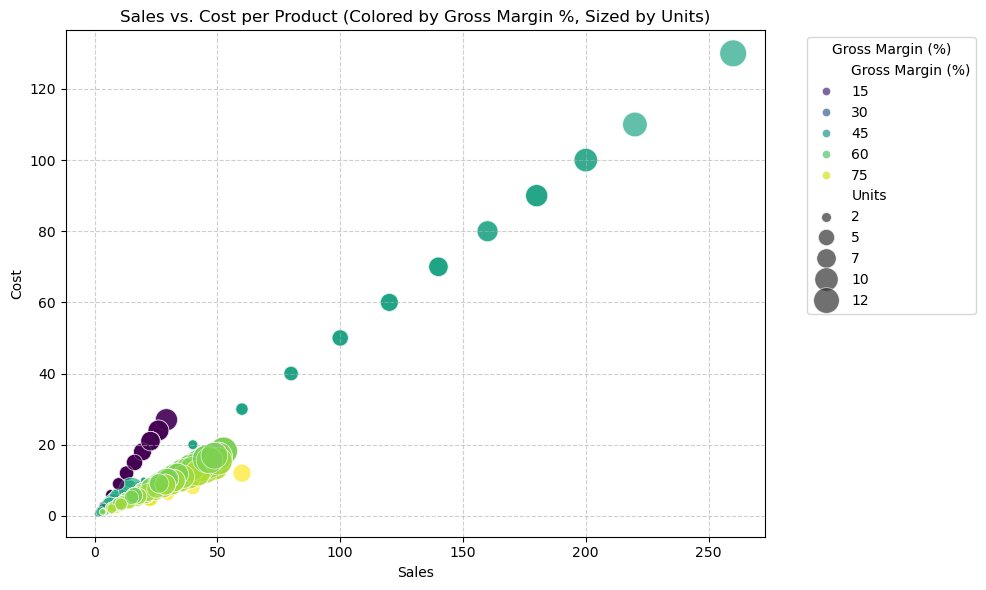

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot of Sales vs. Cost
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Sales', y='Cost', data=df_cleaned, hue='Gross Margin (%)', size='Units', sizes=(20, 400), palette='viridis', alpha=0.7)
plt.title('Sales vs. Cost per Product (Colored by Gross Margin %, Sized by Units)')
plt.xlabel('Sales')
plt.ylabel('Cost')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Gross Margin (%)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Profit Contribution by Division Visualization

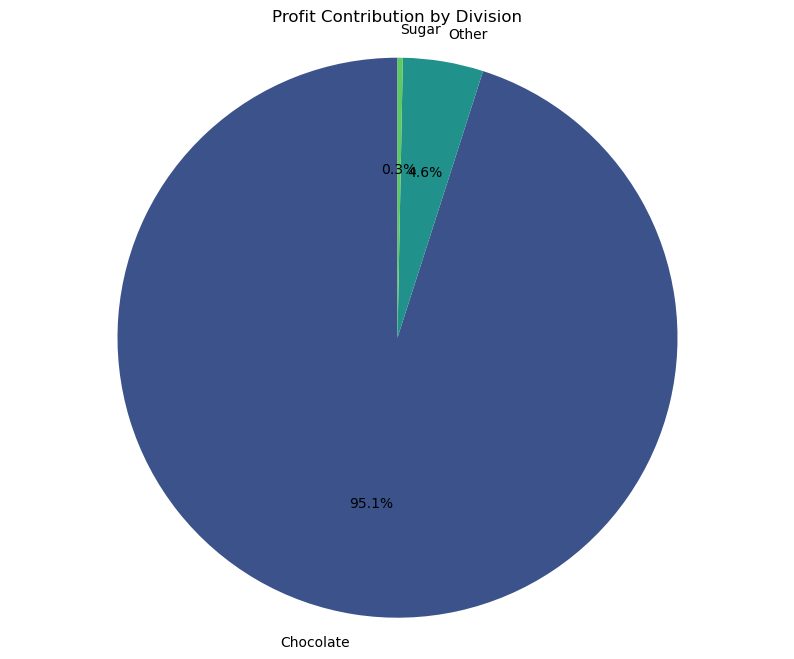

In [65]:

# Prepare data for pie chart
pie_data = division_profitability[['Division', 'Profit Contribution (%)']].copy()

# Plotting the pie chart
plt.figure(figsize=(10, 8))
plt.pie(pie_data['Profit Contribution (%)'], labels=pie_data['Division'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(pie_data)))
plt.title('Profit Contribution by Division')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [67]:
other_division_df = df_cleaned[df_cleaned['Division'] == 'Other'].copy()

other_division_product_profitability = other_division_df.groupby('Product Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Units=('Units', 'sum'),
    Total_Gross_Profit=('Gross Profit', 'sum')
).reset_index()



In [69]:
other_division_product_profitability['Gross Margin (%)'] = (other_division_product_profitability['Total_Gross_Profit'] / other_division_product_profitability['Total_Sales']) * 100
other_division_product_profitability['Profit per Unit'] = other_division_product_profitability['Total_Gross_Profit'] / other_division_product_profitability['Total_Units']

print("\nProducts in 'Other' Division by Gross Margin (%): (Lowest margins first)")
display(other_division_product_profitability.sort_values(by='Gross Margin (%)', ascending=True))


Products in 'Other' Division by Gross Margin (%): (Lowest margins first)


,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Gross Margin (%),Profit per Unit
0,Kazookles,1205.75,371,92.75,7.692308,0.25
1,Lickable Wallpaper,7860.00,393,3930.00,50.000000,10.00
2,Wonka Gum,597.50,478,310.70,52.000000,0.65


In [71]:
rationalization_table = other_division_product_profitability.copy()

# Rank products by Gross Margin (%) and Profit per Unit (lower rank for lower profitability)
rationalization_table['Gross_Margin_Rank'] = rationalization_table['Gross Margin (%)'].rank(ascending=True).astype(int)
rationalization_table['Profit_per_Unit_Rank'] = rationalization_table['Profit per Unit'].rank(ascending=True).astype(int)



In [73]:
# Add a recommendation column based on observed metrics
def get_recommendation(row):
    if row['Gross Margin (%)'] < 10:
        return 'Critical Review: Price/Cost Adjustment, Consider Discontinuation'
    elif row['Gross Margin (%)'] < 50 and row['Profit per Unit'] < 1:
        return 'Investigate Efficiency: Improve Cost Structure or Volume'
    elif row['Gross Margin (%)'] < 60:
        return 'Monitor: Seek Optimization Opportunities'
    else:
        return 'Maintain/Grow: Strong Performer'

rationalization_table['Recommendation'] = rationalization_table.apply(get_recommendation, axis=1)

print("\nProduct Rationalisation Table for 'Other' Division:")
display(rationalization_table.sort_values(by='Gross Margin (%)', ascending=True))


Product Rationalisation Table for 'Other' Division:


,Product Name,Total_Sales,Total_Units,Total_Gross_Profit,Gross Margin (%),Profit per Unit,Gross_Margin_Rank,Profit_per_Unit_Rank,Recommendation
0,Kazookles,1205.75,371,92.75,7.692308,0.25,1,1,"Critical Review: Price/Cost Adjustment, Consid..."
1,Lickable Wallpaper,7860.00,393,3930.00,50.000000,10.00,2,3,Monitor: Seek Optimization Opportunities
2,Wonka Gum,597.50,478,310.70,52.000000,0.65,3,2,Monitor: Seek Optimization Opportunities


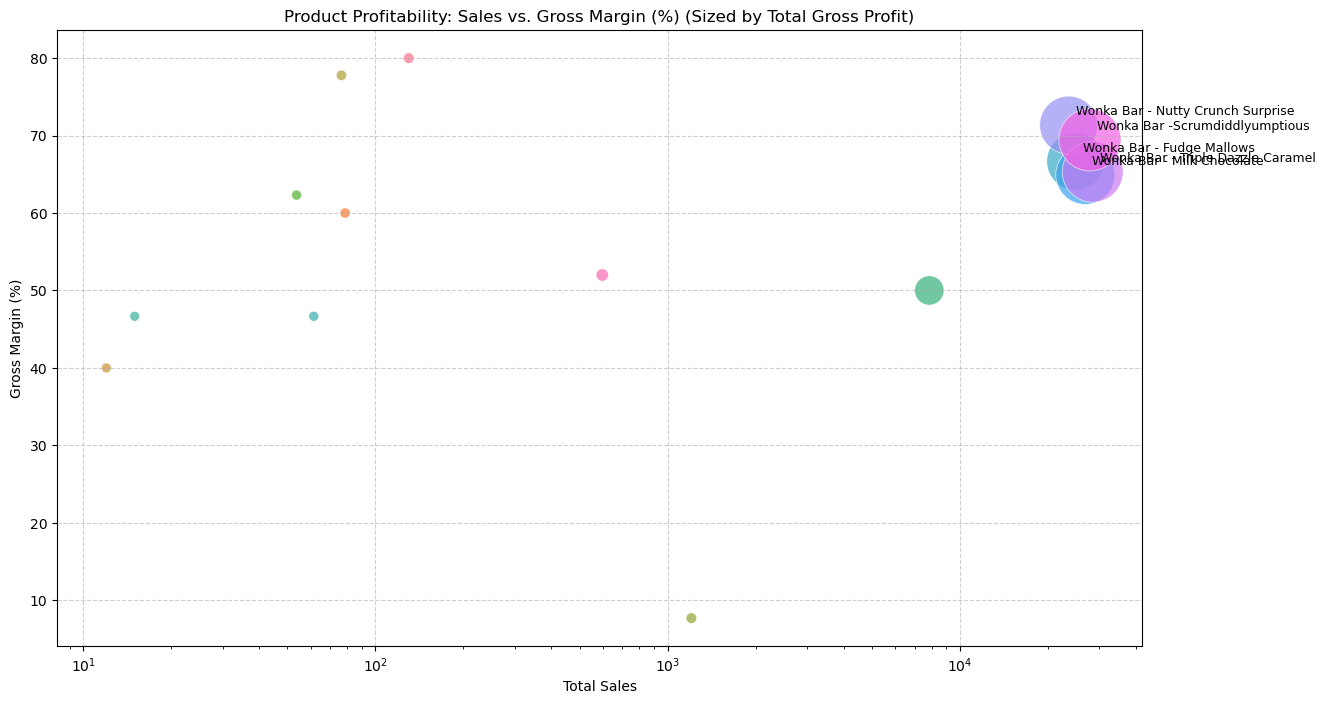

In [87]:

plt.figure(figsize=(14, 8))
sns.scatterplot(
    x='Total_Sales',
    y='Gross Margin (%)',
    size='Total_Gross_Profit',
    sizes=(50, 2000), # Adjust min and max size of points
    hue='Product Name', # Differentiate products by color
    data=product_profitability,
    legend=False, # Disable legend to avoid clutter for many products
    alpha=0.7
)

# Annotate some key products (e.g., top 5 by Total_Gross_Profit) for better readability
top_products = product_profitability.sort_values(by='Total_Gross_Profit', ascending=False).head(5)
for i, row in top_products.iterrows():
    plt.annotate(
        row['Product Name'],
        (row['Total_Sales'], row['Gross Margin (%)']),
        textcoords="offset points",
        xytext=(5,5),
        ha='left',
        va='bottom',
        fontsize=9,
        color='black'
    )

plt.title('Product Profitability: Sales vs. Gross Margin (%) (Sized by Total Gross Profit)')
plt.xlabel('Total Sales')
plt.ylabel('Gross Margin (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.xscale('log') # Use a log scale for sales if there's a wide range
plt.show()

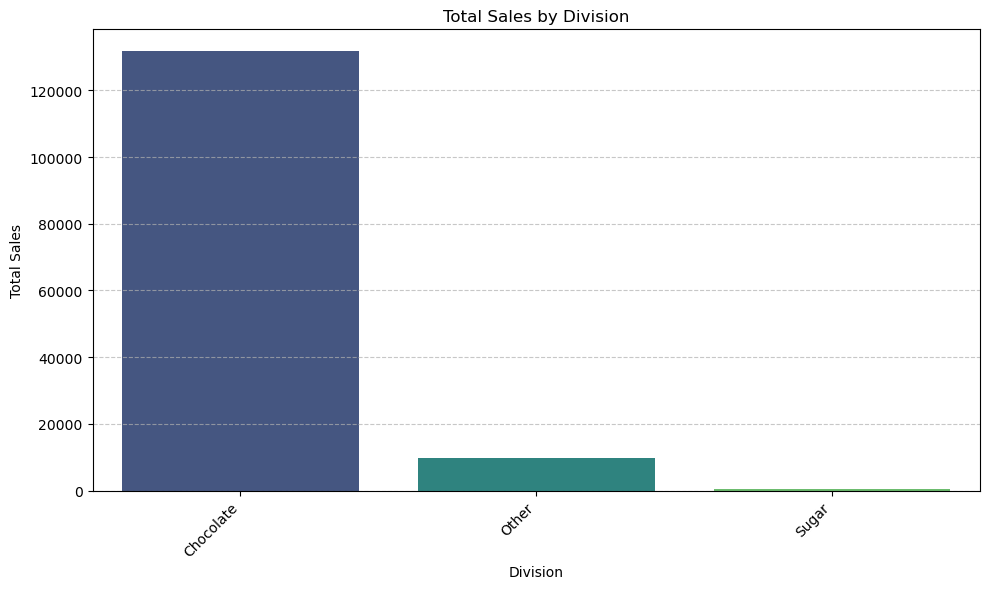

In [89]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Division', y='Total_Sales', hue='Division', data=division_profitability.sort_values(by='Total_Sales', ascending=False), palette='viridis', legend=False)
plt.title('Total Sales by Division')
plt.xlabel('Division')
plt.ylabel('Total Sales')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Sales Trend Analysis for Chocolate Division

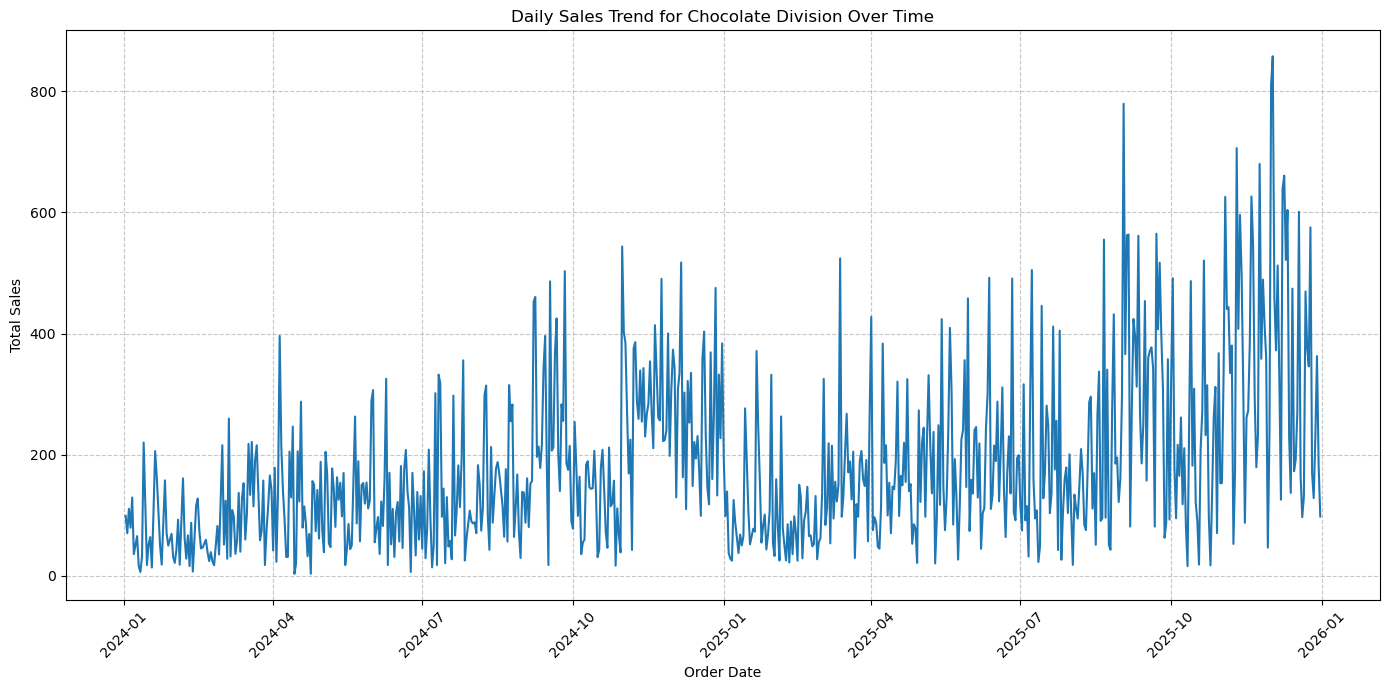

In [92]:
# Filter data for the 'Chocolate' division
chocolate_df = df_cleaned[df_cleaned['Division'] == 'Chocolate'].copy()

# Convert 'Order Date' to datetime objects for time series analysis
chocolate_df['Order Date'] = pd.to_datetime(chocolate_df['Order Date'], format='%d-%m-%Y')

# Aggregate daily sales for the Chocolate division
chocolate_daily_sales = chocolate_df.groupby('Order Date')['Sales'].sum().reset_index()

# Plot the sales trend for the Chocolate division
plt.figure(figsize=(14, 7))
sns.lineplot(x='Order Date', y='Sales', data=chocolate_daily_sales)
plt.title('Daily Sales Trend for Chocolate Division Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Daily Sales Trend Comparison Across Divisions

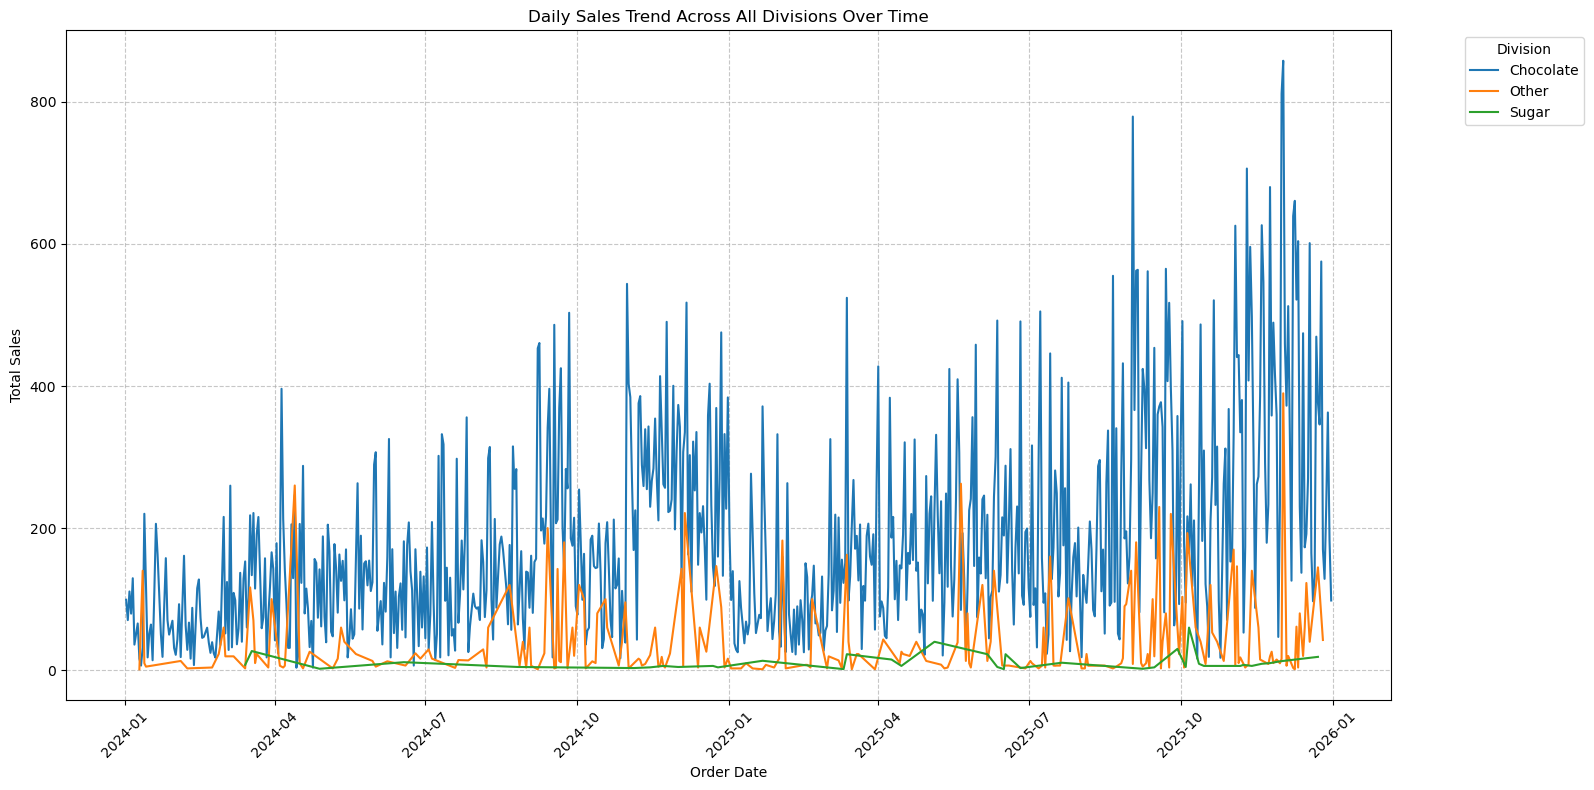

In [95]:
# Ensure 'Order Date' is in datetime format for the entire cleaned DataFrame
df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'], format='%d-%m-%Y')

# Aggregate daily sales for all divisions
daily_sales_all_divisions = df_cleaned.groupby(['Order Date', 'Division'])['Sales'].sum().reset_index()

# Plot the daily sales trend for all divisions
plt.figure(figsize=(16, 8))
sns.lineplot(x='Order Date', y='Sales', hue='Division', data=daily_sales_all_divisions)
plt.title('Daily Sales Trend Across All Divisions Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.legend(title='Division', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Correlation Analysis between Chocolate and Other Divisions' Daily Sales'

In [98]:
# Filter daily sales for Chocolate and Other divisions
chocolate_other_sales = daily_sales_all_divisions[daily_sales_all_divisions['Division'].isin(['Chocolate', 'Other'])]



In [100]:
# Pivot the DataFrame to get daily sales for each division as separate columns
pivoted_sales = chocolate_other_sales.pivot_table(
    index='Order Date',
    columns='Division',
    values='Sales'
).reset_index()



In [102]:
# Calculate the correlation between 'Chocolate' and 'Other' sales
correlation = pivoted_sales['Chocolate'].corr(pivoted_sales['Other'])

print(f"Correlation between Daily Sales of Chocolate and Other Divisions: {correlation:.4f}")

# Display the pivoted sales data for context
print("\nPivoted Daily Sales for Chocolate and Other Divisions (first 5 rows):")
display(pivoted_sales.head())

Correlation between Daily Sales of Chocolate and Other Divisions: 0.1776

Pivoted Daily Sales for Chocolate and Other Divisions (first 5 rows):


Division,Order Date,Chocolate,Other
0,2024-01-02,99.18,NaN
1,2024-01-03,70.50,NaN
2,2024-01-04,110.82,NaN
3,2024-01-05,79.61,NaN
4,2024-01-06,129.43,NaN


Identification of High Sales Dates for Chocolate and Other Divisions

In [107]:
# Identify top 5 dates with highest sales for Chocolate division
top_chocolate_sales_dates = pivoted_sales.sort_values(by='Chocolate', ascending=False).head(5)
print("\nTop 5 Dates with Highest Sales for Chocolate Division:")
display(top_chocolate_sales_dates[['Order Date', 'Chocolate']])




Top 5 Dates with Highest Sales for Chocolate Division:


Division,Order Date,Chocolate
687,2025-12-02,857.87
686,2025-12-01,811.48
596,2025-09-02,779.29
665,2025-11-10,706.15
679,2025-11-24,680.09


In [109]:
# Identify top 5 dates with highest sales for Other division
top_other_sales_dates = pivoted_sales.sort_values(by='Other', ascending=False).head(5)
print("\nTop 5 Dates with Highest Sales for Other Division:")
display(top_other_sales_dates[['Order Date', 'Other']])


Top 5 Dates with Highest Sales for Other Division:


Division,Order Date,Other
687,2025-12-02,389.75
492,2025-05-21,262.50
93,2024-04-13,260.00
612,2025-09-18,229.75
326,2024-12-05,221.25


In [111]:
#CONCLUSION
'''Based on the comprehensive analysis of the Nassau Candy Distributor's sales and profitability data, here are the key conclusions:

Dominance of Chocolate Division: The Chocolate division is the overwhelming primary driver of both revenue (92.88%) and
                      gross profit (95.06%), with a strong gross margin of 67.45%. Its sales trend consistently overshadows other divisions.

Product Profitability Concentration: A significant Pareto principle is at play, with approximately 26.67% of products contributing
                  to 80% of both total revenue and gross profit. "Wonka Bar" variants are key high-profit, high-sales, high-margin products.

'Other' Division for Optimization: The 'Other' division, while having the second-highest sales contribution, exhibits a lower
                gross margin (44.84%) compared to Chocolate, indicating potential structural issues. Specific products within this division,
                such as "Kazookles", have been identified for critical review due to very low gross margins (7.69%).

Weak Inter-Divisional Sales Correlation: The daily sales trends between the 'Chocolate' and 'Other' divisions show a weak 
                                     positive correlation (0.1776), suggesting their sales are largely independent of each other.

High Sales Days: December 2nd, 2025, stands out as a high sales day for both the 'Chocolate' and 
                'Other' divisions, which could be indicative of shared peak demand periods or successful promotional efforts.

In summary, the company's financial health is heavily reliant on its Chocolate division and a concentrated set of high-performing products.
Strategic focus should be placed on maintaining and growing these core strengths, while also critically evaluating and optimizing 
the profitability of products within the 'Other' division, particularly those with low margins like 'Kazookles'.

'''

'Based on the comprehensive analysis of the Nassau Candy Distributor\'s sales and profitability data, here are the key conclusions:\n\nDominance of Chocolate Division: The Chocolate division is the overwhelming primary driver of both revenue (92.88%) and\n                      gross profit (95.06%), with a strong gross margin of 67.45%. Its sales trend consistently overshadows other divisions.\n\nProduct Profitability Concentration: A significant Pareto principle is at play, with approximately 26.67% of products contributing\n                  to 80% of both total revenue and gross profit. "Wonka Bar" variants are key high-profit, high-sales, high-margin products.\n\n\'Other\' Division for Optimization: The \'Other\' division, while having the second-highest sales contribution, exhibits a lower\n                gross margin (44.84%) compared to Chocolate, indicating potential structural issues. Specific products within this division,\n                such as "Kazookles", have been iden